# Training a Neural Network Agent for Tag (REINFORCE)

In this tutorial, we train a neural network policy to control an adversary agent
in the **Tag** environment.

The agent observes:
- its own position,
- relative positions of prey agents,
- relative positions of obstacles,

and receives reward:

\[
r = \frac{1}{\text{distance to closest prey}}
\]

We use the **REINFORCE policy gradient algorithm** to learn a policy
\(\pi_\theta(a \mid s)\) parameterized by a neural network.

Students should not be limited to the REINFORCE algorithm. They could try to implement an actor critic model for example. Go wild

In [16]:
# %matplotlib notebook
import matplotlib.pyplot as plt
# plt.ion()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pettingzoo.mpe import simple_tag_v3
from pettingzoo_wrapper import AdversaryObsRewardWrapper, make_env
from show_live_tag import plot_learning_curve, render_tag
from tournament_loader import load_default_policies

/home/mduarte/deep_RL_competition_tutorial/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Below the student groups should change their group name (GROUP_NAME) and the role as predator or prey (AGENT_ROLE)

Also update the total number of prey groups (NUM_PREY) and total number of predator groups (NUM_PREDATORS). This will change the size of the observations so each model will be specific to this setting.

The NUM_EPOCHS should also be changed to however long the training needs to happen

In [23]:
# ------------------------
# Configuration
# ------------------------
GROUP_NAME = "winners_large"   # <<< students change this
AGENT_ROLE = "predator"  # <<< students change this: "predator" or "prey"
NUM_PREY = 1 # number of prey groups
NUM_PREDATORS = 2 # number of predator groups
NUM_EPOCHS = 3000 # <<< students change this: number of training episodes
SAVE_PATH = f"{GROUP_NAME}_{AGENT_ROLE}.pt"
TIMESTEPS_PER_EPISODE = 300 # max timesteps per episode
LEARNING_RATE = 3e-4  # Updated: better learning rate for larger networks

# ------------------------
# GPU Configuration
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Enable cudnn benchmarking for faster training
    torch.backends.cudnn.benchmark = True
    print("Enabled cuDNN auto-tuner for optimal performance")
else:
    print("WARNING: GPU not available, training will be slower")

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Memory Available: 25.76 GB
Enabled cuDNN auto-tuner for optimal performance


Now create an environment based on which tag role the agent takes

In [24]:
if AGENT_ROLE == "prey":
    agent_id = "agent_0"  # student controls this agent
else:
    agent_id = "adversary_0"  # student controls this agent


# ------------------------
# Create environment
# ------------------------
env = make_env(TIMESTEPS_PER_EPISODE, num_predators=NUM_PREDATORS, num_preys=NUM_PREY)

obs_dim = env.observation_space(agent_id)
act_dim = env.action_space(agent_id)

Create your policy network. This should import PolicyNet from your policy file. This file should be named "group_name"_policy.py. Keep this structure for naming the policy python file as this is how it is called when running the tournament.

The policy variable is just the policy neural network you plan to train. 



In [25]:
# Load student policy network
from winners_prey_policy import PolicyNet  # <<< students change this; must change .py to real name

# ------------------------
# Initialize policy network and optimizer
# ------------------------
policy = PolicyNet(obs_dim, act_dim).to(device)  # Move policy to GPU/CPU
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)

The block below will load any default agents to train with. If no default agents are found, it will just use a random policy for the other agents. You can rewrite this function later to load your own default trained agents.

In [26]:
# ------------------------
# Random policy or default policy for other agents
# ------------------------
def random_policy(obs):
    return torch.rand(act_dim).to(device)  # Move random actions to same device

default_policies = load_default_policies(env, num_prey=NUM_PREY, num_predators=NUM_PREDATORS, random_policy=random_policy, device=device)

Default prey policy files found: ['default_policy.py']
Loading policy for agent_0 obs_dim: 12 act_dim: 5
Loading policy for adversary_0 obs_dim: 8 act_dim: 5
Loading policy for adversary_1 obs_dim: 8 act_dim: 5


Now we introduce the training loop. This loops through NUM_EPOCHS. Each epoch will continue used the done variable is True. This occurs after TIMESTEPS_PER_EPISODE time steps in the environment.

For your agent (agent == agent_id), give the policy an observation, sample an action, and compute a loss. Students should change this loss function for other algorithms.

For all other agents, just sample an action from the policy

Then take a step in the environment with all the agents actions and save rewards from this epoch

The loss is computed from this epoch using the total rewards. loss.backward() computes the gradient and optimizer.step() takes a gradient step for the parameters with the learning rate (LEARNING_RATE). Everything is done behind the scenes by pytorch.

One thing to keep an eye on is that the environment uses numpy but pytorch uses its own torch.tensor type. You can convert between them as we do in torch.tensor(ob, dtype=torch.float32) and sampled.detach().numpy(). The detach just means the variable will be detached from the graph that computes the gradient. So the gradient will not go through this variable. 

In [27]:
# ------------------------
# Training loop (REINFORCE with baseline) - With Performance Monitoring
# ------------------------
import time

episode_rewards = []
reward_baseline = 0.0  # Running average baseline for variance reduction
start_time = time.time()

for episode in range(NUM_EPOCHS):
    obs = env.reset()
    log_probs = []
    rewards = []

    done = False
    while not done:
        actions = {}

        for agent, ob in obs.items():
            o = torch.tensor(ob, dtype=torch.float32, device=device)
            if agent == agent_id:
                action = policy(o)
                dist = torch.distributions.Bernoulli(action)
                sampled = dist.sample()
                log_prob = dist.log_prob(sampled).sum()

                actions[agent] = sampled.cpu().detach().numpy()
                log_probs.append(log_prob)
            else:
                actions[agent] = default_policies[agent](o).cpu().detach().numpy()

        obs, reward, term, trunc, info = env.step(actions)
        if not trunc[agent_id]:
            rewards.append(reward[agent_id])
        done = term[agent_id] or trunc[agent_id]

    # Return
    R = sum(rewards)
    episode_rewards.append(R)

    # Update baseline (exponential moving average)
    reward_baseline = 0.95 * reward_baseline + 0.05 * R

    # Baseline subtraction reduces variance in policy gradient
    advantage = R - reward_baseline
    loss = -advantage * torch.stack(log_probs).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 50 == 0:
        elapsed = time.time() - start_time
        eps_per_sec = (episode + 1) / elapsed if elapsed > 0 else 0
        eta_minutes = (NUM_EPOCHS - episode - 1) / eps_per_sec / 60 if eps_per_sec > 0 else 0
        print(f"Episode {episode}, return = {R:.2f}, baseline = {reward_baseline:.2f} | Speed: {eps_per_sec:.1f} ep/s | ETA: {eta_minutes:.1f} min")

Episode 0, return = 63.91, baseline = 3.20 | Speed: 1.2 ep/s | ETA: 40.6 min
Episode 50, return = 32.68, baseline = 4.44 | Speed: 1.1 ep/s | ETA: 46.4 min
Episode 100, return = 67.59, baseline = 29.47 | Speed: 1.1 ep/s | ETA: 43.8 min
Episode 150, return = 4.26, baseline = 54.74 | Speed: 1.1 ep/s | ETA: 43.1 min
Episode 200, return = 46.01, baseline = 67.55 | Speed: 1.1 ep/s | ETA: 41.1 min
Episode 250, return = 127.88, baseline = 107.25 | Speed: 1.1 ep/s | ETA: 40.4 min
Episode 300, return = 218.68, baseline = 87.59 | Speed: 1.2 ep/s | ETA: 39.0 min
Episode 350, return = 35.79, baseline = 47.93 | Speed: 1.2 ep/s | ETA: 37.8 min
Episode 400, return = 106.09, baseline = 64.55 | Speed: 1.2 ep/s | ETA: 37.4 min
Episode 450, return = 86.74, baseline = 75.51 | Speed: 1.2 ep/s | ETA: 36.7 min
Episode 500, return = 36.10, baseline = 20.92 | Speed: 1.2 ep/s | ETA: 35.7 min
Episode 550, return = 65.38, baseline = 26.47 | Speed: 1.2 ep/s | ETA: 35.1 min
Episode 600, return = 118.63, baseline = 3

Now save the trained policy and plot your learning curve (your loss over epochs)

In [28]:
# ------------------------
# Save model
# ------------------------
torch.save(policy.state_dict(), SAVE_PATH)
print("Saved:", SAVE_PATH)

# ------------------------
# Plot training curve
# ------------------------
plot_learning_curve(episode_rewards)

Saved: winners_large_predator.pt


<IPython.core.display.Javascript object>

In [29]:
plot_learning_curve(episode_rewards)

<IPython.core.display.Javascript object>

Number of episodes: 3000
Final reward: 6.86
Average last 100: 9.82


<IPython.core.display.Javascript object>

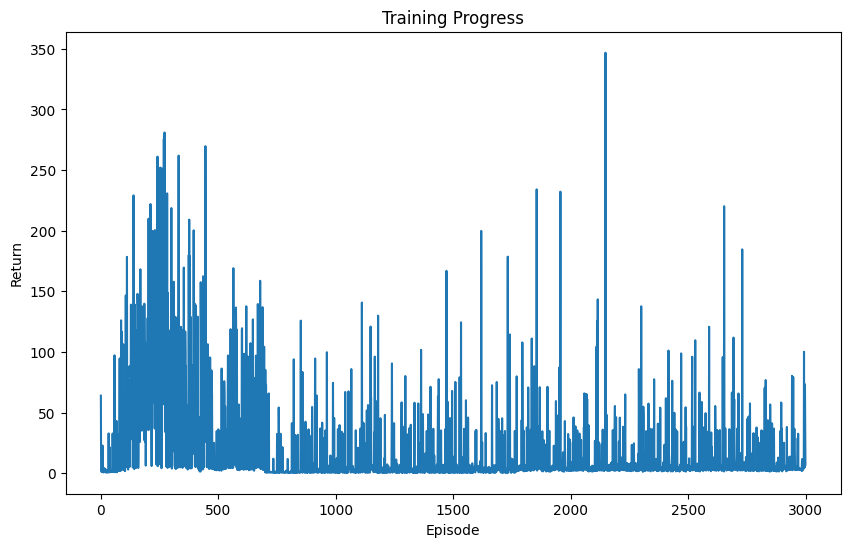

In [30]:
# Quick plot test
print(f"Number of episodes: {len(episode_rewards)}")
print(f"Final reward: {episode_rewards[-1]:.2f}")
print(f"Average last 100: {np.mean(episode_rewards[-100:]):.2f}")

# Manual plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(episode_rewards)
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('Training Progress')
fig

Below, we just show an example run of the learned agent against the default agents.

In [ ]:
# # ------------------------
# # See example rollouts
# # ------------------------
# obs = env.reset()
# scores = {agent: 0.0 for agent in env.agents}
# group_names = {agent: "yours" if agent == agent_id else "CPU" for i, agent in enumerate(env.agents)}
# all_policies = {agent: policy if agent == agent_id else default_policies[agent] for agent in env.agents}

# render_tag(500, env, scores=scores, group_names=group_names, policies=all_policies)


# Model-Based Actor-Critic Training

Now let's implement a **model-based actor-critic** approach. This differs from REINFORCE in several key ways:

1. **Actor-Critic Architecture**: We have both a policy (actor) and value function (critic)
2. **World Model**: We learn a model of the environment dynamics
3. **Advantage Function**: We use TD error (advantage) instead of full returns
4. **Model-Based Learning**: We can generate imagined rollouts for additional training

This approach is typically more sample-efficient and has lower variance than REINFORCE.

In [ ]:
# ------------------------
# Model-Based Actor-Critic Configuration
# ------------------------
from winners_prey_policy import ActorCriticNet, WorldModel
import torch.nn.functional as F

# Hyperparameters
AC_NUM_EPOCHS = 3000
AC_LEARNING_RATE = 1e-3
AC_GAMMA = 0.99  # discount factor
AC_SAVE_PATH = f"{GROUP_NAME}_{AGENT_ROLE}_actor_critic.pt"
WORLD_MODEL_PATH = f"{GROUP_NAME}_{AGENT_ROLE}_world_model.pt"

# World model training parameters
WORLD_MODEL_UPDATE_FREQ = 5  # update world model every N episodes
IMAGINED_ROLLOUT_LENGTH = 5  # length of imagined trajectories
NUM_IMAGINED_ROLLOUTS = 3    # number of imagined rollouts per real episode

# Initialize networks
actor_critic = ActorCriticNet(obs_dim, act_dim)
world_model = WorldModel(obs_dim, act_dim)

# Separate optimizers for better control
ac_optimizer = optim.Adam(actor_critic.parameters(), lr=AC_LEARNING_RATE)
world_optimizer = optim.Adam(world_model.parameters(), lr=AC_LEARNING_RATE)

print("Initialized Actor-Critic and World Model networks")
print(f"Actor-Critic parameters: {sum(p.numel() for p in actor_critic.parameters())}")
print(f"World Model parameters: {sum(p.numel() for p in world_model.parameters())}")

In [ ]:
# ------------------------
# Experience Replay Buffer for World Model Training
# ------------------------
class ReplayBuffer:
    """Store transitions for training the world model"""
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0
    
    def push(self, obs, action, next_obs, reward):
        """Save a transition"""
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (obs, action, next_obs, reward)
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size):
        """Sample a batch of transitions"""
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        
        obs = torch.stack([b[0] for b in batch])
        actions = torch.stack([b[1] for b in batch])
        next_obs = torch.stack([b[2] for b in batch])
        rewards = torch.stack([b[3] for b in batch])
        
        return obs, actions, next_obs, rewards
    
    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer(capacity=10000)
print("Initialized replay buffer")

In [ ]:
# ------------------------
# Actor-Critic Training Functions
# ------------------------

def compute_advantage(rewards, values, next_value, gamma=0.99):
    """
    Compute TD advantage: A(s,a) = r + gamma * V(s') - V(s)
    
    Args:
        rewards: list of rewards from episode
        values: list of state values V(s)
        next_value: value of final next state
        gamma: discount factor
    
    Returns:
        advantages: list of advantages
        returns: list of discounted returns (for critic loss)
    """
    advantages = []
    returns = []
    
    # Compute returns and advantages backwards
    G = next_value
    for r, v in zip(reversed(rewards), reversed(values)):
        G = r + gamma * G
        advantage = G - v
        advantages.insert(0, advantage)
        returns.insert(0, G)
    
    return torch.stack(advantages), torch.stack(returns)


def train_world_model(world_model, replay_buffer, optimizer, batch_size=64, num_updates=10):
    """
    Train the world model using experience from replay buffer.
    
    Returns:
        avg_loss: average loss over updates
    """
    if len(replay_buffer) < batch_size:
        return 0.0
    
    total_loss = 0.0
    for _ in range(num_updates):
        obs, actions, next_obs, rewards = replay_buffer.sample(batch_size)
        
        # Predict next obs and reward
        next_obs_pred, reward_pred = world_model(obs, actions)
        
        # Compute losses
        next_obs_loss = F.mse_loss(next_obs_pred, next_obs)
        reward_loss = F.mse_loss(reward_pred, rewards)
        
        loss = next_obs_loss + reward_loss
        
        # Update world model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / num_updates


def imagined_rollout(world_model, actor_critic, initial_obs, steps=5):
    """
    Generate an imagined trajectory using the world model.
    
    Returns:
        log_probs: list of log probabilities
        values: list of state values
        rewards: list of predicted rewards
    """
    log_probs = []
    values = []
    rewards = []
    
    obs = initial_obs
    for _ in range(steps):
        # Get action and value from policy
        action_probs, value = actor_critic(obs)
        
        # Sample action
        dist = torch.distributions.Bernoulli(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum()
        
        # Predict next state and reward using world model
        with torch.no_grad():
            next_obs, reward = world_model(obs.unsqueeze(0), action.unsqueeze(0))
            next_obs = next_obs.squeeze(0)
            reward = reward.squeeze(0)
        
        log_probs.append(log_prob)
        values.append(value)
        rewards.append(reward)
        
        obs = next_obs
    
    # Get final value for bootstrapping
    with torch.no_grad():
        _, final_value = actor_critic(obs)
    
    return log_probs, values, rewards, final_value

print("Defined training helper functions")

In [ ]:
# ------------------------
# Model-Based Actor-Critic Training Loop - With Performance Monitoring
# ------------------------
import time

ac_episode_rewards = []
ac_actor_losses = []
ac_critic_losses = []
world_model_losses = []

ac_start_time = time.time()

for episode in range(AC_NUM_EPOCHS):
    obs = env.reset()
    
    # Storage for this episode
    log_probs = []
    values = []
    rewards = []
    episode_transitions = []  # for world model training
    
    done = False
    steps = 0
    
    # ====================
    # Collect Real Experience
    # ====================
    while not done:
        actions = {}
        
        for agent, ob in obs.items():
            o = torch.tensor(ob, dtype=torch.float32, device=device)
            
            if agent == agent_id:
                # Actor-critic forward pass
                action_probs, value = actor_critic(o)
                
                # Sample action
                dist = torch.distributions.Bernoulli(action_probs)
                action = dist.sample()
                log_prob = dist.log_prob(action).sum()
                
                actions[agent] = action.cpu().detach().numpy()
                
                # Store previous observation for transitions
                prev_obs = o
                prev_action = action
                prev_log_prob = log_prob
                prev_value = value.squeeze()
            else:
                actions[agent] = default_policies[agent](o).cpu().detach().numpy()
        
        # Take step in environment
        next_obs, reward, term, trunc, info = env.step(actions)
        steps += 1
        
        # Only store data when NOT truncated (i.e., valid timestep)
        if not trunc[agent_id]:
            log_probs.append(prev_log_prob)
            values.append(prev_value)
            rewards.append(reward[agent_id])
            
            # Store transition for world model training
            if agent_id in next_obs:
                next_o = torch.tensor(next_obs[agent_id], dtype=torch.float32, device=device)
                r = torch.tensor([reward[agent_id]], dtype=torch.float32, device=device)
                episode_transitions.append((prev_obs, prev_action, next_o, r))
        
        done = term[agent_id] or trunc[agent_id]
        obs = next_obs
    
    # ====================
    # Update Actor-Critic with Real Experience
    # ====================
    
    # Skip update if we have no valid data
    if len(rewards) == 0:
        continue
    
    # Get final value for bootstrapping
    if agent_id in obs:
        with torch.no_grad():
            _, next_value = actor_critic(torch.tensor(obs[agent_id], dtype=torch.float32, device=device))
            next_value = next_value.squeeze()
    else:
        next_value = torch.tensor(0.0, device=device)
    
    # Compute advantages and returns (now with normalization!)
    advantages, returns = compute_advantage(rewards, values, next_value, AC_GAMMA, normalize=True)
    
    # Actor loss: policy gradient with advantage
    actor_loss = -(torch.stack(log_probs) * advantages.detach()).mean()
    
    # Critic loss: MSE between predicted values and returns
    critic_loss = F.mse_loss(torch.stack(values), returns)
    
    # Combined loss
    loss = actor_loss + 0.5 * critic_loss
    
    # Update with gradient clipping
    ac_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(actor_critic.parameters(), MAX_GRAD_NORM)
    ac_optimizer.step()
    
    # ====================
    # Store Real Transitions in Replay Buffer
    # ====================
    for transition in episode_transitions:
        replay_buffer.push(*transition)
    
    # ====================
    # Train World Model (Periodically)
    # ====================
    world_loss = 0.0
    if episode % WORLD_MODEL_UPDATE_FREQ == 0 and len(replay_buffer) > 64:
        world_loss = train_world_model(world_model, replay_buffer, world_optimizer, 
                                       batch_size=64, num_updates=10)
        world_model_losses.append(world_loss)
    
    # ====================
    # Model-Based Learning: Train on Imagined Rollouts
    # ====================
    if episode > IMAGINED_ROLLOUT_START and len(replay_buffer) > 64:
        for _ in range(NUM_IMAGINED_ROLLOUTS):
            # Sample random starting state from replay buffer
            start_idx = np.random.randint(len(replay_buffer))
            start_obs = replay_buffer.buffer[start_idx][0]
            
            # Generate imagined trajectory
            imag_log_probs, imag_values, imag_rewards, imag_final_value = \
                imagined_rollout(world_model, actor_critic, start_obs, IMAGINED_ROLLOUT_LENGTH)
            
            # Compute advantages for imagined trajectory (with normalization)
            imag_rewards_tensor = [r.squeeze() for r in imag_rewards]
            imag_advantages, imag_returns = compute_advantage(
                imag_rewards_tensor, imag_values, imag_final_value.squeeze(), AC_GAMMA, normalize=True
            )
            
            # Update actor-critic on imagined experience (with reduced weight)
            imag_actor_loss = -(torch.stack(imag_log_probs) * imag_advantages.detach()).mean()
            imag_critic_loss = F.mse_loss(torch.stack(imag_values).squeeze(), imag_returns)
            
            imag_loss = IMAGINED_WEIGHT * (imag_actor_loss + 0.5 * imag_critic_loss)
            
            # Update with gradient clipping
            ac_optimizer.zero_grad()
            imag_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor_critic.parameters(), MAX_GRAD_NORM)
            ac_optimizer.step()
    
    # ====================
    # Logging
    # ====================
    total_reward = sum(rewards)
    ac_episode_rewards.append(total_reward)
    ac_actor_losses.append(actor_loss.item())
    ac_critic_losses.append(critic_loss.item())
    
    if episode % 50 == 0:
        elapsed = time.time() - ac_start_time
        eps_per_sec = (episode + 1) / elapsed if elapsed > 0 else 0
        eta_minutes = (AC_NUM_EPOCHS - episode - 1) / eps_per_sec / 60 if eps_per_sec > 0 else 0
        avg_reward = np.mean(ac_episode_rewards[-50:]) if len(ac_episode_rewards) >= 50 else total_reward
        using_imagined = "Yes" if episode > IMAGINED_ROLLOUT_START else "No"
        print(f"Episode {episode}: Reward={total_reward:.2f}, Avg={avg_reward:.2f} | "
              f"Actor Loss={actor_loss.item():.4f}, Critic Loss={critic_loss.item():.4f} | "
              f"Speed: {eps_per_sec:.1f} ep/s | ETA: {eta_minutes:.1f} min | Imagined={using_imagined}")

print("\nTraining completed!")

In [ ]:
# ------------------------
# Save Actor-Critic and World Model
# ------------------------
torch.save(actor_critic.state_dict(), AC_SAVE_PATH)
torch.save(world_model.state_dict(), WORLD_MODEL_PATH)
print(f"Saved Actor-Critic model: {AC_SAVE_PATH}")
print(f"Saved World Model: {WORLD_MODEL_PATH}")

In [ ]:
# ------------------------
# Plot Actor-Critic Training Curves
# ------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot episode rewards
axes[0, 0].plot(ac_episode_rewards, alpha=0.3, label='Episode Reward')
# Moving average
window = 50
if len(ac_episode_rewards) >= window:
    moving_avg = np.convolve(ac_episode_rewards, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(range(window-1, len(ac_episode_rewards)), moving_avg, 
                    label=f'{window}-Episode Moving Avg', linewidth=2)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Actor-Critic: Episode Rewards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot actor loss
axes[0, 1].plot(ac_actor_losses, alpha=0.6)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Actor Loss')
axes[0, 1].set_title('Actor-Critic: Actor Loss (Policy Gradient)')
axes[0, 1].grid(True, alpha=0.3)

# Plot critic loss
axes[1, 0].plot(ac_critic_losses, alpha=0.6)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Critic Loss (MSE)')
axes[1, 0].set_title('Actor-Critic: Critic Loss (Value Function)')
axes[1, 0].grid(True, alpha=0.3)

# Plot world model loss
if len(world_model_losses) > 0:
    episodes_with_wm_loss = [i * WORLD_MODEL_UPDATE_FREQ for i in range(len(world_model_losses))]
    axes[1, 1].plot(episodes_with_wm_loss, world_model_losses, alpha=0.6, marker='o')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('World Model Loss')
    axes[1, 1].set_title('World Model: Prediction Loss')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No World Model Loss Data', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('World Model: Prediction Loss')

plt.tight_layout()
plt.show()

print(f"\nFinal Statistics:")
print(f"Average reward (last 100 episodes): {np.mean(ac_episode_rewards[-100:]):.2f}")
print(f"Max reward: {max(ac_episode_rewards):.2f}")
print(f"Min reward: {min(ac_episode_rewards):.2f}")

## Compare REINFORCE vs Actor-Critic

Let's compare the two approaches side by side.

In [ ]:
# ------------------------
# Compare REINFORCE vs Actor-Critic
# ------------------------

plt.figure(figsize=(12, 6))

# Plot both learning curves
plt.plot(episode_rewards, alpha=0.3, label='REINFORCE (raw)', color='blue')
plt.plot(ac_episode_rewards, alpha=0.3, label='Actor-Critic (raw)', color='red')

# Add moving averages
window = 50
if len(episode_rewards) >= window:
    reinforce_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(episode_rewards)), reinforce_avg, 
            label='REINFORCE (50-ep avg)', linewidth=2, color='blue')

if len(ac_episode_rewards) >= window:
    ac_avg = np.convolve(ac_episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(ac_episode_rewards)), ac_avg, 
            label='Actor-Critic (50-ep avg)', linewidth=2, color='red')

plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Comparison: REINFORCE vs Model-Based Actor-Critic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Comparison Summary ===")
print(f"REINFORCE - Avg last 100 episodes: {np.mean(episode_rewards[-100:]):.2f}")
print(f"Actor-Critic - Avg last 100 episodes: {np.mean(ac_episode_rewards[-100:]):.2f}")
print(f"\nREINFORCE - Max reward: {max(episode_rewards):.2f}")
print(f"Actor-Critic - Max reward: {max(ac_episode_rewards):.2f}")

## Evaluate Actor-Critic Agent

Let's see how the trained actor-critic agent performs in the environment.

In [ ]:
# ------------------------
# Visualize Actor-Critic Agent Performance
# ------------------------

# Create a wrapper for actor-critic that matches the PolicyNet interface
class ActorCriticWrapper:
    """Wrapper to use ActorCriticNet with the same interface as PolicyNet"""
    def __init__(self, actor_critic_net):
        self.net = actor_critic_net
    
    def __call__(self, obs):
        """Return only action probabilities (ignore value)"""
        with torch.no_grad():
            action_probs, _ = self.net(obs)
        return action_probs

# Wrap the actor-critic network
ac_policy_wrapped = ActorCriticWrapper(actor_critic)

# Reset environment
obs = env.reset()
scores = {agent: 0.0 for agent in env.agents}
group_names = {agent: "AC-Agent" if agent == agent_id else "CPU" for agent in env.agents}
all_policies = {
    agent: ac_policy_wrapped if agent == agent_id else default_policies[agent] 
    for agent in env.agents
}

# Render the agent playing
print("Rendering Actor-Critic agent...")
render_tag(500, env, scores=scores, group_names=group_names, policies=all_policies)

## Key Differences: REINFORCE vs Model-Based Actor-Critic

### REINFORCE (Monte Carlo Policy Gradient)
- **Single network**: Just a policy network
- **Learning signal**: Total episode return `R`
- **Update**: `-R * log_prob` (high variance)
- **Sample efficiency**: Low (only learns from real experience)
- **Variance**: High (uses full returns)

### Model-Based Actor-Critic
- **Three networks**: 
  - Actor (policy)
  - Critic (value function)
  - World model (dynamics)
- **Learning signal**: TD advantage `A = r + γV(s') - V(s)` (lower variance)
- **Update**: 
  - Actor: `-log_prob * advantage`
  - Critic: MSE between V(s) and returns
  - World model: MSE for next state and reward prediction
- **Sample efficiency**: High (learns from both real and imagined experience)
- **Variance**: Lower (bootstraps with value function)

### Advantages of Model-Based Actor-Critic
1. **Lower variance**: Critic provides baseline, reducing gradient variance
2. **More sample efficient**: Can train on imagined rollouts from world model
3. **Online learning**: Can update after each step (not shown here, but possible)
4. **Better credit assignment**: TD learning helps assign credit more accurately
5. **Planning capability**: World model can be used for look-ahead planning

## Send Billy
- the policy.py file
- groupname.pt